In [1]:
import gspread
import pandas as pd
import matplotlib.pyplot as plt

from google.oauth2.service_account import Credentials

In [2]:
SERVICE_ACCOUNT_FILE = 'key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('LLM Kula').worksheet('data_LLM')
data = sheet.get_all_values()

df = pd.DataFrame(data[2:], columns=data[1])

In [11]:
df

,date,validator,scenario_category,sub_category,detail_category,Result,LLM_dislike_reason
0,1/22/2026,Aulia,Angsuran dan Pinjaman,Dana pinjaman tidak sesuai,Pinjaman,Like,
1,1/22/2026,Aulia,Angsuran dan Pinjaman,Dana pinjaman tidak sesuai,Pinjaman,Like,
2,1/22/2026,Aulia,Angsuran dan Pinjaman,Dana pinjaman tidak sesuai,Pinjaman,Dislike,jawaban LLM tidak sesuai dengan FAQ
3,1/22/2026,Aulia,Angsuran dan Pinjaman,Dana pinjaman tidak sesuai,Pinjaman,Like,
4,1/22/2026,Aulia,Angsuran dan Pinjaman,Dana pinjaman tidak sesuai,Pinjaman,Like,
...,...,...,...,...,...,...,...
1235,2/12/2026,Reza,Angsuran dan Pinjaman,Apa itu biaya angsuran?,Payment Gateway,Like,
1236,2/12/2026,Reza,Angsuran dan Pinjaman,Apa itu biaya angsuran?,Payment Gateway,Like,
1237,2/12/2026,Reza,Angsuran dan Pinjaman,Apa itu biaya angsuran?,Payment Gateway,Like,
1238,2/12/2026,Reza,Angsuran dan Pinjaman,Apa itu biaya angsuran?,Payment Gateway,Like,


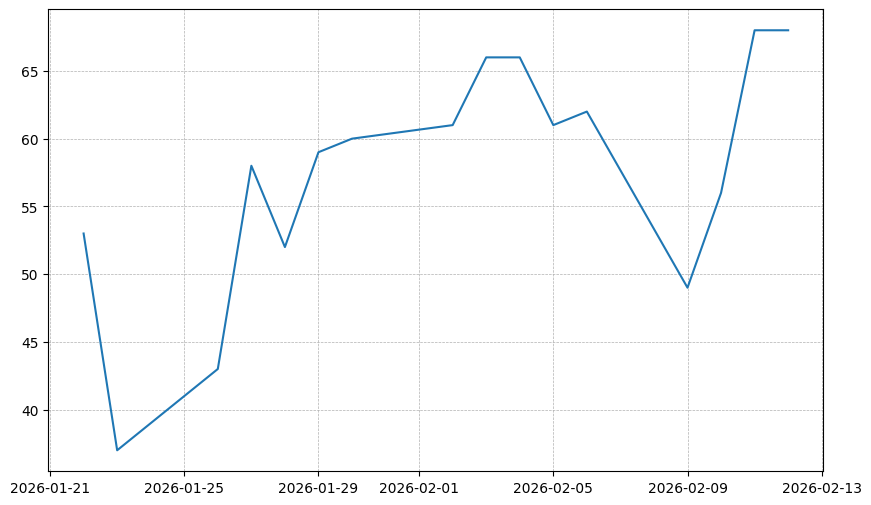

: 

In [ ]:
vis = (
    df.copy()
    .iloc[:,[0,5]]
)

vis['date'] = pd.to_datetime(vis['date'], format='%m/%d/%Y')
vis['Result'] = vis['Result'].astype('category')
vis['count'] = vis['Result'].apply(lambda x: 1 if x == 'Like' else 0).astype('int')

vis = vis.groupby('date')['count'].sum()

plt.figure(figsize=(10, 6))
plt.plot(vis.index, vis.values)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.title('')